In [1]:
!git clone https://github.com/mohammedumairuddin/EEEM073-AI-Sustainability-coursework.git

Cloning into 'EEEM073-AI-Sustainability-coursework'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 104 (delta 45), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 2.27 MiB | 4.05 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [2]:
cd EEEM073-AI-Sustainability-coursework/

/content/EEEM073-AI-Sustainability-coursework


In [3]:
!ls

datasets  models  notebooks  README.md	requirements.txt  results


In [4]:
cd datasets

/content/EEEM073-AI-Sustainability-coursework/datasets


In [5]:
!ls

crop_production.csv


In [6]:

import pandas as pd

df = pd.read_csv("crop_production.csv")
df.head()


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [38]:
import os

os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/metrics", exist_ok=True)
os.makedirs("results/reports", exist_ok=True)

In [7]:

import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)


In [8]:

from sklearn.model_selection import train_test_split

df["Yield"] = df["Production"] / df["Area"]

X = df.drop("Yield", axis=1)
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
print(df.dtypes)
print(X_train.select_dtypes(include="object").columns)

State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
Yield            float64
dtype: object
Index(['State_Name', 'District_Name', 'Season', 'Crop'], dtype='object')


In [10]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["State_Name","District_Name","Season","Crop"]:
    df[col] = le.fit_transform(df[col])


In [11]:

from sklearn.model_selection import train_test_split

X = df.drop("Yield", axis=1)
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
print(X_train.dtypes)

State_Name         int64
District_Name      int64
Crop_Year          int64
Season             int64
Crop               int64
Area             float64
Production       float64
dtype: object


In [13]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(0)

In [14]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.feature_selection import SelectKBest,f_regression

selector = SelectKBest(score_func=f_regression,k=5)

X_new = selector.fit_transform(X_train,y_train)

In [17]:
from sklearn.ensemble import RandomForestRegressor

compressed_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=5
)

compressed_rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=5, n_estimators=50)

Model Compression techniques


In [18]:
import pandas as pd
import numpy as np
import time
import os
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error

In [19]:
#Train Baseline models(Baseline = uncompressed)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

start = time.time()

rf.fit(X_train, y_train)

train_time_baseline = time.time() - start

In [20]:
#predictions
start = time.time()

y_pred_baseline = rf.predict(X_test)

inference_time_baseline = time.time() - start

In [21]:
#Evaluating baseline model
baseline_r2 = r2_score(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("Baseline R2:", baseline_r2)
print("Baseline RMSE:", baseline_rmse)

Baseline R2: 0.9516245855497497
Baseline RMSE: 161.7712801679476


In [22]:
joblib.dump(rf, "../models/baseline_rf.pkl")

['../models/baseline_rf.pkl']

In [23]:
baseline_size = os.path.getsize("../models/baseline_rf.pkl")/(1024*1024)

print("Baseline Model Size:", baseline_size, "MB")

Baseline Model Size: 9.602570533752441 MB


Compression Technique 1 — Feature Selection


In [24]:
selector = SelectKBest(
    score_func=f_regression,
    k=5
)

X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)

In [25]:
#training model with reduced features for compression
rf_fs = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

start = time.time()

rf_fs.fit(X_train_fs, y_train)

train_time_fs = time.time() - start

In [26]:
start = time.time()

y_pred_fs = rf_fs.predict(X_test_fs)

inference_time_fs = time.time() - start

In [27]:
#evaluation
fs_r2 = r2_score(y_test, y_pred_fs)
fs_rmse = np.sqrt(mean_squared_error(y_test, y_pred_fs))

print("Feature Selection R2:", fs_r2)
print("Feature Selection RMSE:", fs_rmse)

Feature Selection R2: 0.8630432850410952
Feature Selection RMSE: 272.1953727943711


In [28]:
joblib.dump(rf_fs, "../models/fs_rf.pkl")

fs_size = os.path.getsize("../models/fs_rf.pkl")/(1024*1024)

Compression Technique 2 — Model Pruning to Reduce complexity of Random Forest.

In [29]:
compressed_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=5,
    random_state=42
)

In [30]:
#training model
start = time.time()

compressed_rf.fit(X_train, y_train)

train_time_compressed = time.time() - start

In [31]:
start = time.time()

y_pred_compressed = compressed_rf.predict(X_test)

inference_time_compressed = time.time() - start

In [32]:
compressed_r2 = r2_score(y_test, y_pred_compressed)
compressed_rmse = np.sqrt(mean_squared_error(y_test, y_pred_compressed))

print("Compressed R2:", compressed_r2)
print("Compressed RMSE:", compressed_rmse)

Compressed R2: 0.8898510199153709
Compressed RMSE: 244.10648264360555


In [33]:
joblib.dump(compressed_rf, "../models/compressed_rf.pkl")

compressed_size = os.path.getsize("../models/compressed_rf.pkl")/(1024*1024)

Performance Comparison evaluation - Tables

In [34]:
results = pd.DataFrame({

"Model":[
"Baseline Random Forest",
"Feature Selection RF",
"Compressed RF"
],

"R2":[
baseline_r2,
fs_r2,
compressed_r2
],

"RMSE":[
baseline_rmse,
fs_rmse,
compressed_rmse
],

"Model Size (MB)":[
baseline_size,
fs_size,
compressed_size
],

"Inference Time (s)":[
inference_time_baseline,
inference_time_fs,
inference_time_compressed
]

})

results

,Model,R2,RMSE,Model Size (MB),Inference Time (s)
0,Baseline Random Forest,0.951625,161.771280,9.602571,0.630743
1,Feature Selection RF,0.863043,272.195373,12.140672,0.714344
2,Compressed RF,0.889851,244.106483,0.216676,0.060698


Visualizations

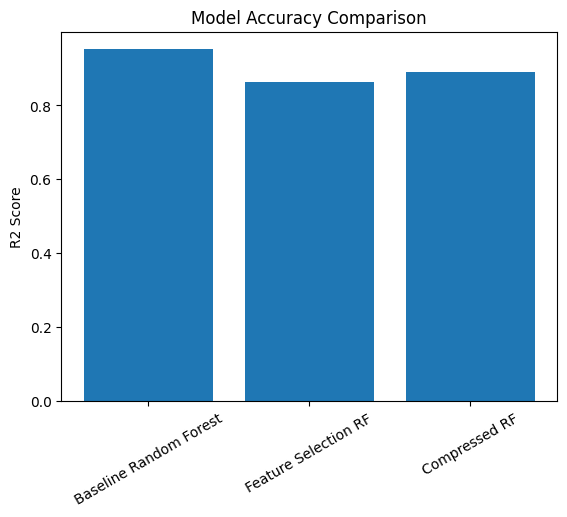

In [42]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["R2"])
plt.title("Model Accuracy Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.savefig("results/plots/model_accuracy.png", dpi=300)

plt.show()

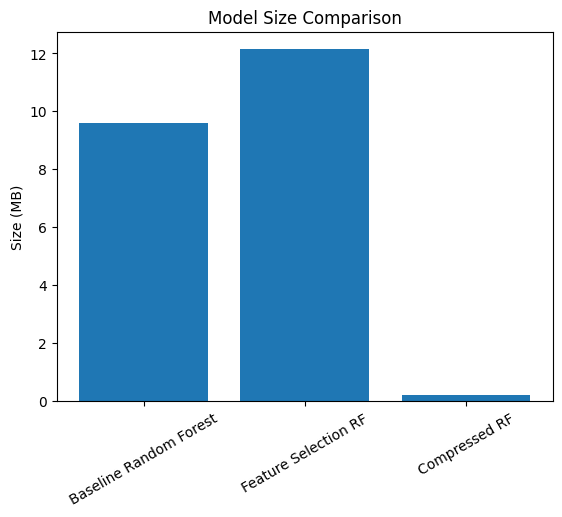

In [43]:
plt.bar(results["Model"], results["Model Size (MB)"])
plt.title("Model Size Comparison")
plt.ylabel("Size (MB)")
plt.xticks(rotation=30)
plt.savefig("results/plots/model_size_comparison.png", dpi=300)
plt.show()

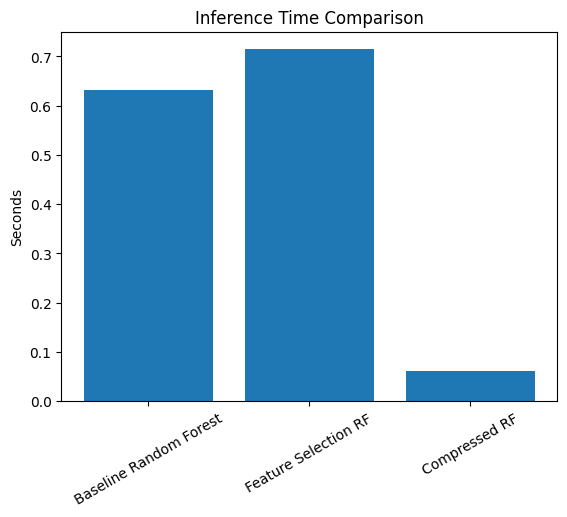

In [44]:
plt.bar(results["Model"], results["Inference Time (s)"])
plt.title("Inference Time Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=30)

plt.savefig("results/plots/inference_time.png", dpi=300)
plt.show()

In [39]:
results.to_csv("results/metrics/model_results.csv", index=False)

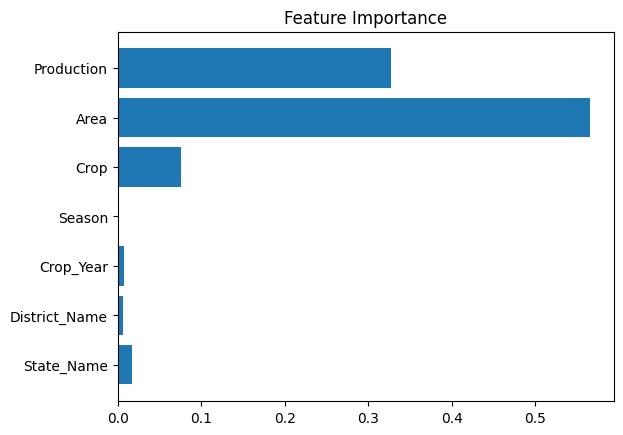

In [45]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X_train.columns

plt.barh(features, importances)

plt.title("Feature Importance")

plt.savefig("results/plots/feature_importance.png", dpi=300)

plt.show()

In [47]:
import joblib

joblib.dump(rf, "../models/baseline_rf.pkl")
joblib.dump(rf_fs, "../models/fs_rf.pkl")
joblib.dump(compressed_rf, "../models/compressed_rf.pkl")

['../models/compressed_rf.pkl']

In [48]:
with open("results/reports/experiment_summary.txt", "w") as f:

    f.write("Crop Yield Prediction Project\n\n")

    f.write("Baseline Model R2: " + str(baseline_r2) + "\n")
    f.write("Feature Selection Model R2: " + str(fs_r2) + "\n")
    f.write("Compressed Model R2: " + str(compressed_r2) + "\n\n")

    f.write("Baseline Model Size: " + str(baseline_size) + " MB\n")
    f.write("Compressed Model Size: " + str(compressed_size) + " MB\n")